In [104]:
import pandas as pd
import numpy as np
import yfinance as yf

In [105]:
start = "2020-9-01"
end = "2024-10-01"

symbol = "007660.KS"

df = yf.download(symbol, start, end)

[*********************100%***********************]  1 of 1 completed


In [106]:
# 지수 이동 평균(EMA) 계산 함수
def calculate_ema(data, span):
    return data.ewm(span=span, adjust=False).mean()

# MACD 계산 함수
def calculate_macd(data, short_window=12, long_window=26, signal_window=9):
    # MACD선: 12일 EMA - 26일 EMA
    short_ema = calculate_ema(data['Close'], span=short_window)  # 12일 EMA
    long_ema = calculate_ema(data['Close'], span=long_window)    # 26일 EMA
    macd = short_ema - long_ema
    
    # Signal선: MACD의 9일 EMA
    signal = calculate_ema(macd, span=signal_window)
    
    # MACD 히스토그램: MACD선 - Signal선
    macd_histogram = macd - signal
    
    return macd, signal, macd_histogram

# MACD 계산 및 데이터프레임에 추가
df['MACD'], df['Signal'], df['MACD_Histogram'] = calculate_macd(df)


In [107]:
# # 볼린저밴드 계산 함수
# def calculate_bollinger_bands(data, window=20, num_std=2):
#     # 중심선(SMA 계산)
#     sma = data['Close'].rolling(window=window).mean()
    
#     # 표준편차 계산
#     rolling_std = data['Close'].rolling(window=window).std()
    
#     # 상단 밴드와 하단 밴드 계산
#     upper_band = sma + (rolling_std * num_std)
#     lower_band = sma - (rolling_std * num_std)
    
#     return sma, upper_band, lower_band

# # 볼린저 밴드 계산 및 데이터프레임에 추가
# df['SMA'], df['Upper Band'], df['Lower Band'] = calculate_bollinger_bands(df)

In [108]:
# # RSI 계산 함수
# def calculate_rsi(data, window=14):
#     delta = data['Close'].diff()  # Close 가격의 변화량
    
#     gain = delta.where(delta > 0, 0)  # 상승분 (음수는 0으로 처리)
#     loss = -delta.where(delta < 0, 0)  # 하락분 (양수는 0으로 처리, 절댓값)
    
#     avg_gain = gain.rolling(window=window, min_periods=window).mean()[:window+1].to_numpy()
#     avg_loss = loss.rolling(window=window, min_periods=window).mean()[:window+1].to_numpy()
    
#     # 이후에는 지수 이동 평균(EMA) 사용
#     for i in range(window + 1, len(data)):
#         avg_gain = np.append(avg_gain, (avg_gain[-1] * (window - 1) + gain.iloc[i]) / window)
#         avg_loss = np.append(avg_loss, (avg_loss[-1] * (window - 1) + loss.iloc[i]) / window)
    
#     rs = avg_gain / avg_loss  # RS 계산
#     rsi = 100 - (100 / (1 + rs))  # RSI 계산
    
#     return pd.Series(rsi, index=data.index)

# # 데이터프레임에 RSI 열 추가
# df['RSI'] = calculate_rsi(df)

In [109]:
# df = df.loc['2020-10-01':]
# df

In [110]:
from sklearn.preprocessing import MinMaxScaler

# 스케일을 적용할 column을 정의합니다.
scale_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

# MinMaxScaler를 사용하여 데이터 스케일링
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[scale_cols])

# 스케일된 데이터를 DataFrame으로 변환
scaled_df = pd.DataFrame(scaled, columns=scale_cols)

# 다음 날의 주가 상승 여부를 타겟으로 정의
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# NaN 값을 가진 마지막 행 제거 (shift로 인해 마지막 행은 NaN이 될 수 있음)
df = df.dropna()

# 독립 변수 (X)와 종속 변수 (y) 설정
X = scaled_df  # 스케일된 독립 변수들
y = df['Target']  # 상승(1), 하락(0) 여부 (종속 변수)

In [111]:
# 훈련 데이터와 테스트 데이터로 분리
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [112]:
# import xgboost as xgb

# # DMatrix로 데이터 변환
# dtrain = xgb.DMatrix(X_train, label=y_train)
# dtest = xgb.DMatrix(X_test, label=y_test)

# # XGBoost 하이퍼 파라미터 설정
# param = {
#     'max_depth': 5,                 # 나무의 깊이
#     'eta': 0.01,                    # 학습률 (learning rate)
#     'subsample': 0.8,               # 각 트리에 사용할 데이터 샘플 비율
#     'colsample_bytree': 0.8,        # 각 트리에 사용할 피처의 비율
#     'objective': 'binary:logistic', # 이진 분류
#     'eval_metric': 'auc',           # 평가 지표로 AUC 사용
#     'random_state': 42              # 결과 재현성을 위한 랜덤 시드 설정
# }

# # 학습할 부스팅 라운드 수
# num_round = 100

# # 학습 데이터는 'train', 테스트 데이터는 'val'로 설정
# eval_list = [(dtrain, 'train'), (dtest, 'val')]

In [113]:
# # 필요한 라이브러리 불러오기
# from xgboost import XGBClassifier
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import accuracy_score, classification_report

# # XGBoost 분류 모델 초기화
# xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# # 하이퍼파라미터 그리드 설정
# # 확장된 하이퍼파라미터 그리드 설정
# param_grid = {
#     'n_estimators': [100, 200, 300, 500],  # 더 큰 범위로 설정
#     'max_depth': [3, 4, 5, 6],             # 기존 값에 추가 범위 확장
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],  # 더 넓은 학습률 범위
#     'subsample': [0.8, 0.9, 1.0],          # 세밀하게 탐색
#     'colsample_bytree': [0.6, 0.8, 1.0],   # 더 작은 값을 추가하여 탐색
#     'gamma': [0, 0.1, 0.2, 0.3],           # 모델 복잡도를 조절하는 파라미터 추가
#     'min_child_weight': [1, 3, 5]          # 과적합 방지를 위한 파라미터 추가
# }

# # GridSearchCV 설정 (cv=5는 5-fold cross validation)
# grid_search = GridSearchCV(
#     estimator=xgb,
#     param_grid=param_grid,
#     cv=5,
#     scoring='accuracy',
#     n_jobs=-1,  # 가능한 모든 CPU 코어 사용
#     verbose=2
# )

# # 그리드 서치 실행 (훈련)
# grid_search.fit(X_train, y_train)

# # 최적의 하이퍼파라미터 출력
# print("Best Parameters:", grid_search.best_params_)

# # 최적의 모델로 예측
# best_model = grid_search.best_estimator_
# y_pred = best_model.predict(X_test)

# # 정확도와 평가 결과 출력
# accuracy = accuracy_score(y_test, y_pred)
# print(f"Accuracy: {accuracy}")
# print("Classification Report:\n", classification_report(y_test, y_pred))


In [114]:
# 필요한 라이브러리 불러오기
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# XGBoost 분류 모델 초기화
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# 하이퍼파라미터 그리드 설정
# 확장된 하이퍼파라미터 그리드 설정
param_grid = {
    'n_estimators': [80, 100],  # 더 큰 범위로 설정
    'max_depth': [2, 3],             # 기존 값에 추가 범위 확장
    'learning_rate': [0.005, 0.007, 0.01],  # 더 넓은 학습률 범위
    'subsample': [1.0],          # 세밀하게 탐색
    'colsample_bytree': [0.8],   # 더 작은 값을 추가하여 탐색
    'gamma': [0],           # 모델 복잡도를 조절하는 파라미터 추가
    'min_child_weight': [1]         # 과적합 방지를 위한 파라미터 추가
}

# Best Parameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 1.0}

# GridSearchCV 설정 (cv=5는 5-fold cross validation)
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,  # 가능한 모든 CPU 코어 사용
    verbose=2
)

# 그리드 서치 실행 (훈련)
grid_search.fit(X_train, y_train)

# 최적의 하이퍼파라미터 출력
print("Best Parameters:", grid_search.best_params_)

# 최적의 모델로 예측
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# 정확도와 평가 결과 출력
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print("Classification Report:\n", classification_report(y_test, y_pred))


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.005, 'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 80, 'subsample': 1.0}
Accuracy: 0.5223880597014925
Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.99      0.68       105
           1       0.50      0.01      0.02        96

    accuracy                           0.52       201
   macro avg       0.51      0.50      0.35       201
weighted avg       0.51      0.52      0.37       201



C:\Users\조영서\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [22:23:46] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [115]:
# # XGBoost 모델 학습
# xgb_model = xgb.train(params=param, dtrain=dtrain, num_boost_round=num_round, evals=eval_list, early_stopping_rounds=10)

# # 테스트 데이터 예측
# y_pred_prob = xgb_model.predict(dtest)

AttributeError: 'XGBClassifier' object has no attribute 'train'

In [116]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, ConfusionMatrixDisplay

# 예측된 값을 이진 분류로 변환 (0.5 이상이면 1, 그렇지 않으면 0)
y_pred_binary = (y_pred_prob >= 0.5).astype(int)

# 정확도 평가
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 52.24%


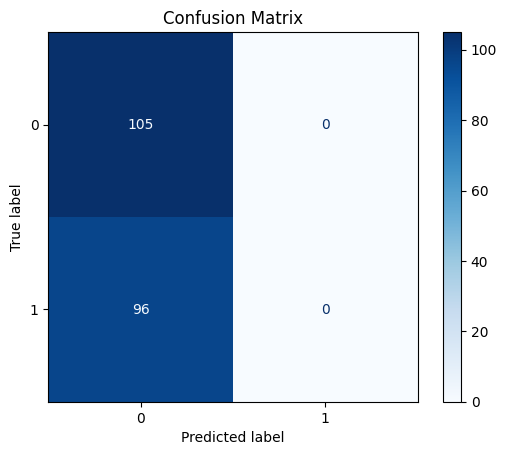

In [117]:
import matplotlib.pyplot as plt

# 혼동 행렬 시각화
cm = confusion_matrix(y_test, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

# 피처 중요도 시각화
plot_importance(xgb_model).set_yticklabels(["Open", "High", "Low", "Close","Volume"])
plt.show()